# 🎯 Linear & Quadratic Discriminant Analysis (LDA & QDA)

A close cousin of Gaussian Naive Bayes: both model each class as a Gaussian distribution and classify via Bayes' theorem. The difference is exactly the "naive" independence assumption — LDA/QDA model the **full covariance matrix** between features (capturing correlations Naive Bayes ignores), closing the loop back to the Math Refresher's covariance matrix and eigenvector sections.

📖 Full mathematical explanation (shared vs per-class covariance, linear/quadratic boundary derivation, LDA as dimensionality reduction): [README.md](README.md)


## 1. Setup & Recap — From GaussianNB to LDA/QDA

GaussianNB assumed each feature was independent given the class (diagonal covariance). LDA and QDA drop that assumption and model the true, full covariance matrix — the same $\Sigma$ matrix from the Math Refresher's statistics section.


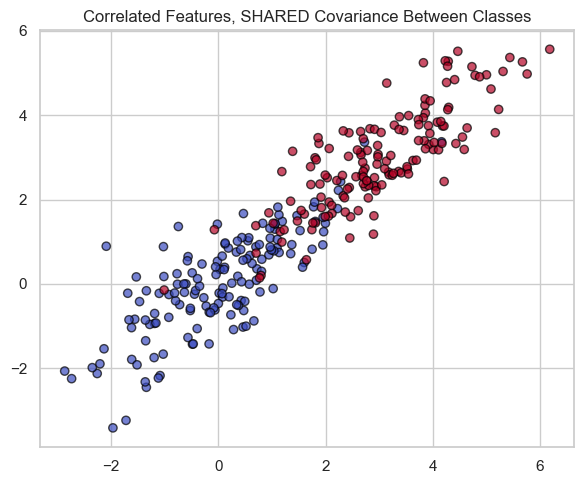

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_wine
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Correlated features WITHIN each class -- exactly what GaussianNB's independence assumption misses
mean_0, mean_1 = [0, 0], [3, 3]
cov_shared = [[1.5, 1.2], [1.2, 1.5]]   # same covariance for both classes -- the LDA assumption

X_0 = np.random.multivariate_normal(mean_0, cov_shared, 150)
X_1 = np.random.multivariate_normal(mean_1, cov_shared, 150)
X_2d = np.vstack([X_0, X_1])
y_2d = np.array([0]*150 + [1]*150)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black", alpha=0.7)
ax.set_title("Correlated Features, SHARED Covariance Between Classes")
plt.tight_layout()
plt.show()


## 2. Why Correlation Matters — GaussianNB vs Reality

GaussianNB would fit an axis-aligned Gaussian per feature per class, missing the diagonal correlation structure entirely. Visualizing what GaussianNB "sees" vs the true data shape makes the gap concrete.


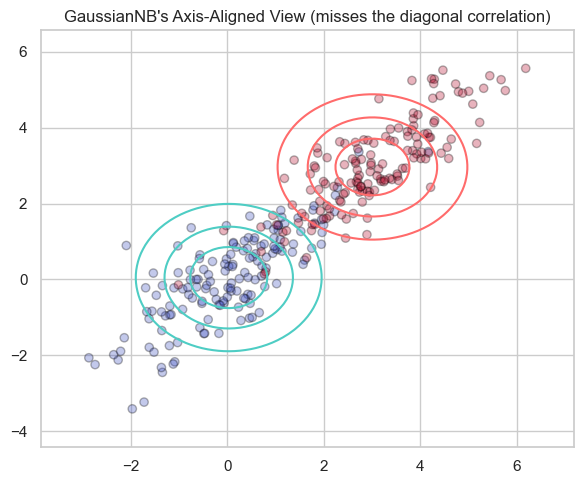

In [2]:
gnb = GaussianNB().fit(X_2d, y_2d)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black", alpha=0.3)

# Overlay GaussianNB's (axis-aligned, independence-assuming) contours
from scipy.stats import multivariate_normal
x_range = np.linspace(X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1, 100)
y_range = np.linspace(X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1, 100)
xx, yy = np.meshgrid(x_range, y_range)
pos = np.dstack((xx, yy))

for i, color in enumerate(["#4ecdc4", "#ff6b6b"]):
    diag_cov = np.diag(gnb.var_[i])   # GaussianNB stores only per-feature variance -- diagonal, no correlation
    rv = multivariate_normal(gnb.theta_[i], diag_cov)
    ax.contour(xx, yy, rv.pdf(pos), levels=3, colors=color)

ax.set_title("GaussianNB's Axis-Aligned View (misses the diagonal correlation)")
plt.tight_layout()
plt.show()


## 3. LDA — Shared Covariance, Linear Boundary

LDA assumes every class shares the **same** covariance matrix $\Sigma$ (only the means differ). Under this assumption, the decision boundary between any two classes is provably **linear** — full derivation in the README.


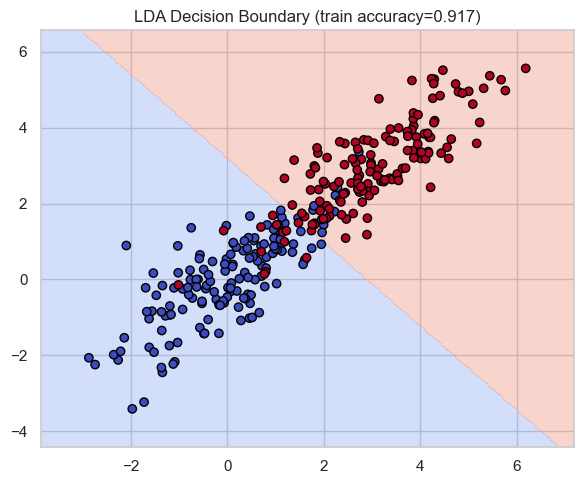

In [3]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_2d, y_2d)

x_range = np.linspace(X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1, 300)
y_range = np.linspace(X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1, 300)
xx, yy = np.meshgrid(x_range, y_range)
Z = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, levels=2, cmap="coolwarm", alpha=0.3)
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black")
ax.set_title(f"LDA Decision Boundary (train accuracy={accuracy_score(y_2d, lda.predict(X_2d)):.3f})")
plt.tight_layout()
plt.show()


## 4. QDA — Per-Class Covariance, Quadratic Boundary

QDA relaxes the shared-covariance assumption: each class gets its **own** covariance matrix. This makes the boundary **quadratic** (curved) — more flexible, but with more parameters to estimate (risk of overfitting on small data).


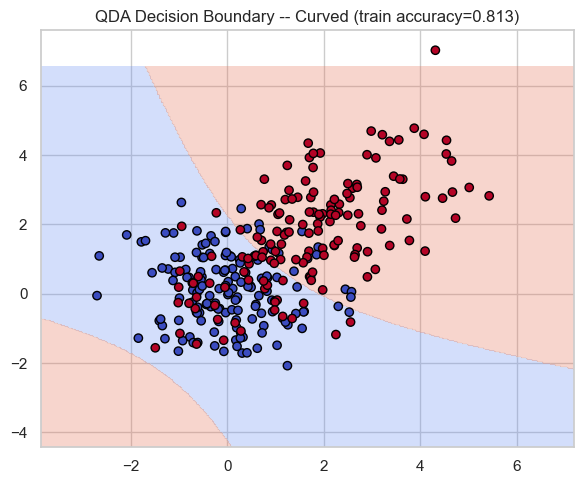

In [4]:
# Build a dataset where covariance genuinely DIFFERS between classes -- QDA's actual use case
mean_a, mean_b = [0, 0], [2, 2]
cov_a = [[1.0, 0.0], [0.0, 1.0]]     # class A: circular spread
cov_b = [[2.5, 1.8], [1.8, 2.5]]     # class B: elongated, correlated spread

X_a = np.random.multivariate_normal(mean_a, cov_a, 150)
X_b = np.random.multivariate_normal(mean_b, cov_b, 150)
X_diff_cov = np.vstack([X_a, X_b])
y_diff_cov = np.array([0]*150 + [1]*150)

qda = QuadraticDiscriminantAnalysis().fit(X_diff_cov, y_diff_cov)
Z_qda = qda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z_qda, levels=2, cmap="coolwarm", alpha=0.3)
ax.scatter(X_diff_cov[:, 0], X_diff_cov[:, 1], c=y_diff_cov, cmap="coolwarm", edgecolor="black")
ax.set_title(f"QDA Decision Boundary -- Curved (train accuracy={accuracy_score(y_diff_cov, qda.predict(X_diff_cov)):.3f})")
plt.tight_layout()
plt.show()


## 5. LDA vs QDA — Which Wins When?

Fitting the *wrong* assumption costs accuracy: LDA on genuinely-different-covariance data underfits (forces a straight line where a curve is needed); QDA on genuinely-shared-covariance data overfits (estimates more parameters than the data actually supports). Testing both models on both datasets makes this a measured comparison, not just a claim.


In [5]:
datasets = {"Shared covariance (LDA's assumption holds)": (X_2d, y_2d),
            "Different covariance (QDA's assumption holds)": (X_diff_cov, y_diff_cov)}

for name, (X, y) in datasets.items():
    lda_score = cross_val_score(LinearDiscriminantAnalysis(), X, y, cv=5).mean()
    qda_score = cross_val_score(QuadraticDiscriminantAnalysis(), X, y, cv=5).mean()
    print(f"{name}:")
    print(f"  LDA CV accuracy: {lda_score:.4f}")
    print(f"  QDA CV accuracy: {qda_score:.4f}\n")


Shared covariance (LDA's assumption holds):
  LDA CV accuracy: 0.9167
  QDA CV accuracy: 0.9200

Different covariance (QDA's assumption holds):
  LDA CV accuracy: 0.8033
  QDA CV accuracy: 0.8033



## 6. LDA as Dimensionality Reduction

Unlike QDA, LDA has a second life: `.transform()` projects data onto up to $(k-1)$ "discriminant axes" ($k$ = number of classes) that **maximize class separation** — a supervised alternative to PCA's variance-maximizing (but label-blind) axes.


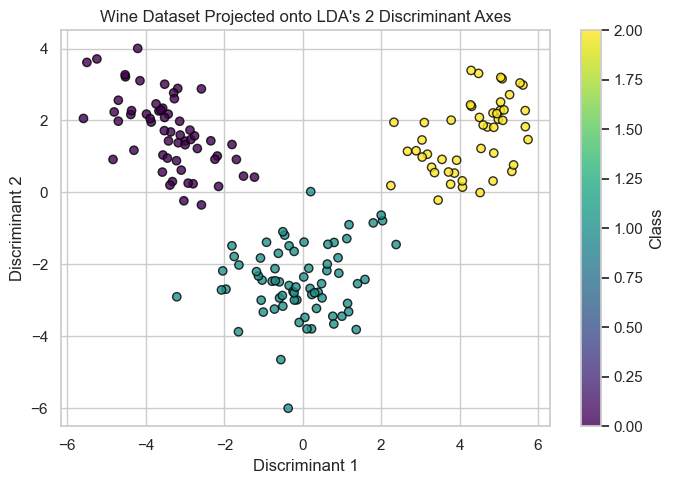

Variance explained by each discriminant axis: [0.687 0.313]


In [6]:
wine = load_wine(as_frame=True)
X_wine, y_wine = wine.data, wine.target
X_wine_scaled = StandardScaler().fit_transform(X_wine)

lda_wine = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda_wine.fit_transform(X_wine_scaled, y_wine)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(X_lda[:, 0], X_lda[:, 1], c=y_wine, cmap="viridis", edgecolor="black", alpha=0.8)
ax.set_title("Wine Dataset Projected onto LDA's 2 Discriminant Axes")
ax.set_xlabel("Discriminant 1"); ax.set_ylabel("Discriminant 2")
plt.colorbar(scatter, label="Class")
plt.tight_layout()
plt.show()

print(f"Variance explained by each discriminant axis: {lda_wine.explained_variance_ratio_.round(3)}")


## 7. LDA vs PCA — Supervised vs Unsupervised Projection

PCA finds directions of maximum **variance**, ignoring labels entirely. LDA finds directions of maximum **class separation**, using labels directly. Side-by-side on the same data makes the difference visible: PCA can accidentally align with a direction that mixes classes together.


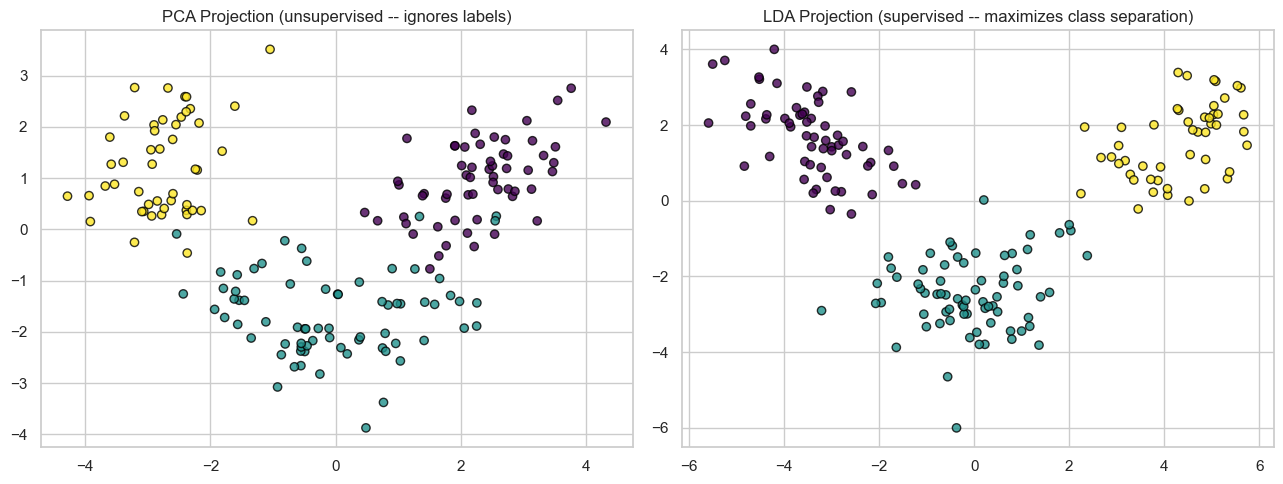

-> LDA's projection typically separates the 3 wine classes more cleanly, since it explicitly
   optimizes for that, while PCA only cares about variance regardless of class labels.


In [7]:
pca_wine = PCA(n_components=2).fit_transform(X_wine_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(pca_wine[:, 0], pca_wine[:, 1], c=y_wine, cmap="viridis", edgecolor="black", alpha=0.8)
axes[0].set_title("PCA Projection (unsupervised -- ignores labels)")
axes[1].scatter(X_lda[:, 0], X_lda[:, 1], c=y_wine, cmap="viridis", edgecolor="black", alpha=0.8)
axes[1].set_title("LDA Projection (supervised -- maximizes class separation)")
plt.tight_layout()
plt.show()

print("-> LDA's projection typically separates the 3 wine classes more cleanly, since it explicitly")
print("   optimizes for that, while PCA only cares about variance regardless of class labels.")


## 8. Real Dataset — Wine Classification

Wine is a classic LDA benchmark: 13 continuous, genuinely correlated chemical features (alcohol, malic acid, ash, etc.), 3 classes — exactly the setting LDA/QDA were designed for.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_wine_scaled, y_wine, test_size=0.2, stratify=y_wine, random_state=42)

lda_model = LinearDiscriminantAnalysis().fit(X_train, y_train)
qda_model = QuadraticDiscriminantAnalysis().fit(X_train, y_train)

lda_acc = accuracy_score(y_test, lda_model.predict(X_test))
qda_acc = accuracy_score(y_test, qda_model.predict(X_test))

print(f"LDA test accuracy: {lda_acc:.4f}")
print(f"QDA test accuracy: {qda_acc:.4f}")
print("\n", classification_report(y_test, lda_model.predict(X_test), target_names=wine.target_names))


LDA test accuracy: 0.9444
QDA test accuracy: 1.0000

               precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



## 9. Confusion Matrix — Wine Dataset (LDA)


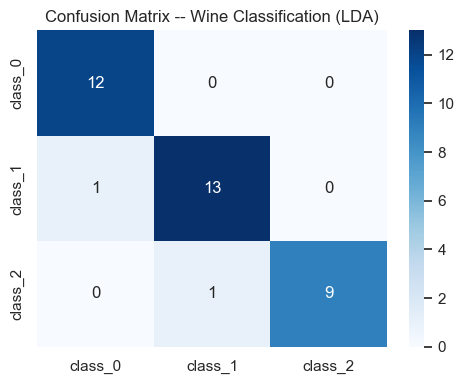

In [9]:
cm = confusion_matrix(y_test, lda_model.predict(X_test))
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=wine.target_names, yticklabels=wine.target_names)
ax.set_title("Confusion Matrix -- Wine Classification (LDA)")
plt.tight_layout()
plt.show()


## 10. LDA vs QDA vs GaussianNB — Three Covariance Assumptions, Head to Head

All three model Gaussian class-conditional distributions; the only difference is how much covariance structure each is allowed to use. Comparing all three directly on Wine quantifies exactly what that assumption costs or gains here.


In [10]:
models = {
    "GaussianNB (diagonal, per-class covariance)": GaussianNB(),
    "LDA (full, SHARED covariance)": LinearDiscriminantAnalysis(),
    "QDA (full, PER-CLASS covariance)": QuadraticDiscriminantAnalysis(),
}

for name, model in models.items():
    score = cross_val_score(model, X_wine_scaled, y_wine, cv=5).mean()
    print(f"{name:42s} -> CV accuracy: {score:.4f}")


GaussianNB (diagonal, per-class covariance) -> CV accuracy: 0.9663
LDA (full, SHARED covariance)              -> CV accuracy: 0.9717
QDA (full, PER-CLASS covariance)           -> CV accuracy: 0.9551


## 11. Covariance Matrix Estimation — Why QDA Needs More Data

QDA estimates a full $d \times d$ covariance matrix **per class** ($k$ classes → $k \cdot \frac{d(d+1)}{2}$ parameters); LDA estimates just **one** shared matrix ($\frac{d(d+1)}{2}$ parameters). More parameters mean more data needed to estimate them reliably — the notebook checks how each model's accuracy responds as training set size shrinks.


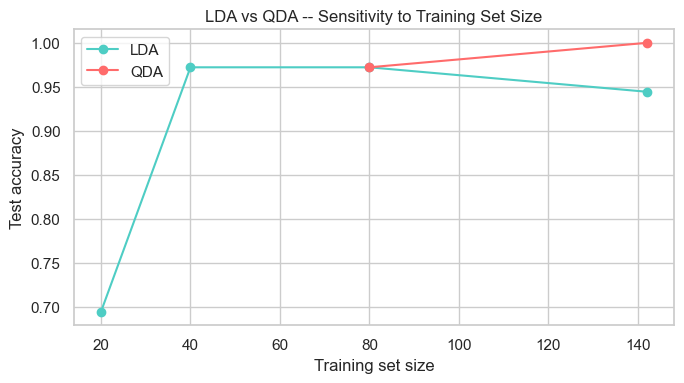

n= 20: LDA=0.6944, QDA=FAILED TO FIT (singular covariance matrix)
n= 40: LDA=0.9722, QDA=FAILED TO FIT (singular covariance matrix)
n= 80: LDA=0.9722, QDA=0.9722
n=142: LDA=0.9444, QDA=1.0000

-> LDA pools all classes into ONE shared covariance estimate, so it never runs out of data this way.
   QDA's per-class covariance requirement is a real, sometimes hard, data-size constraint -- not just a soft cost.


In [11]:
sample_sizes = [20, 40, 80, 142]   # 142 = full training set size
lda_by_size, qda_by_size = [], []

for n in sample_sizes:
    idx = np.random.RandomState(0).choice(len(X_train), size=n, replace=False)
    X_sub, y_sub = X_train[idx], y_train.values[idx] if hasattr(y_train, "values") else y_train[idx]
    lda_by_size.append(accuracy_score(y_test, LinearDiscriminantAnalysis().fit(X_sub, y_sub).predict(X_test)))
    try:
        qda_acc = accuracy_score(y_test, QuadraticDiscriminantAnalysis().fit(X_sub, y_sub).predict(X_test))
    except np.linalg.LinAlgError:
        # QDA needs MORE samples than features in EVERY class to estimate a full covariance matrix --
        # with 13 features and only ~20 samples split across 3 classes, one class can fall short and
        # QDA can't even fit at all. This failure mode IS the point of this section, not a bug to hide.
        qda_acc = np.nan
    qda_by_size.append(qda_acc)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sample_sizes, lda_by_size, marker="o", label="LDA", color="#4ecdc4")
ax.plot(sample_sizes, qda_by_size, marker="o", label="QDA", color="#ff6b6b")
ax.set_xlabel("Training set size"); ax.set_ylabel("Test accuracy")
ax.set_title("LDA vs QDA -- Sensitivity to Training Set Size")
ax.legend()
plt.tight_layout()
plt.show()

for n, lda_a, qda_a in zip(sample_sizes, lda_by_size, qda_by_size):
    qda_display = f"{qda_a:.4f}" if not np.isnan(qda_a) else "FAILED TO FIT (singular covariance matrix)"
    print(f"n={n:>3}: LDA={lda_a:.4f}, QDA={qda_display}")
print("\n-> LDA pools all classes into ONE shared covariance estimate, so it never runs out of data this way.")
print("   QDA's per-class covariance requirement is a real, sometimes hard, data-size constraint -- not just a soft cost.")


## 12. Multiclass LDA — 3-Class Synthetic Boundary

LDA generalizes cleanly beyond binary classification — with $k$ classes, it computes $k$ linear discriminant functions and predicts whichever scores highest, producing a partition of the plane into $k$ linear regions.


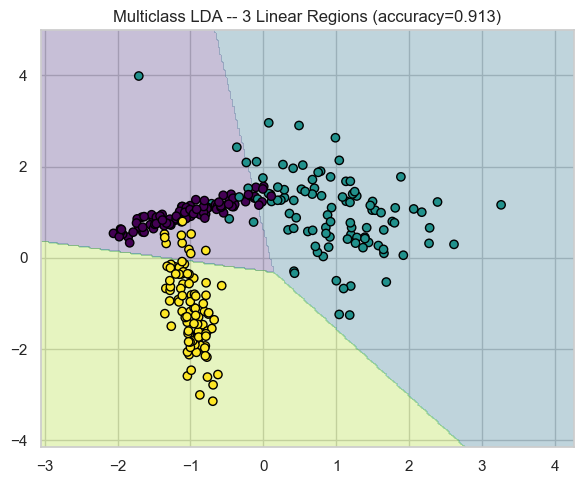

In [12]:
X_multi, y_multi = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0,
    n_classes=3, n_clusters_per_class=1, random_state=42
)

lda_multi = LinearDiscriminantAnalysis().fit(X_multi, y_multi)

x_range = np.linspace(X_multi[:, 0].min() - 1, X_multi[:, 0].max() + 1, 300)
y_range = np.linspace(X_multi[:, 1].min() - 1, X_multi[:, 1].max() + 1, 300)
xx, yy = np.meshgrid(x_range, y_range)
Z = lda_multi.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, levels=3, cmap="viridis", alpha=0.3)
ax.scatter(X_multi[:, 0], X_multi[:, 1], c=y_multi, cmap="viridis", edgecolor="black")
ax.set_title(f"Multiclass LDA -- 3 Linear Regions (accuracy={accuracy_score(y_multi, lda_multi.predict(X_multi)):.3f})")
plt.tight_layout()
plt.show()


## 13. Regularized (Shrinkage) LDA

When features are numerous relative to sample size, the estimated covariance matrix can become unstable (or singular). **Shrinkage** blends the estimated covariance with a simpler, more stable identity-like matrix — a regularization idea structurally similar to Ridge's weight-shrinkage, applied to a covariance matrix instead of a weight vector.


In [13]:
for shrinkage in [None, 0.1, 0.5, 0.9]:
    if shrinkage is None:
        model = LinearDiscriminantAnalysis(solver="lsqr")
    else:
        model = LinearDiscriminantAnalysis(solver="lsqr", shrinkage=shrinkage)
    score = cross_val_score(model, X_wine_scaled, y_wine, cv=5).mean()
    print(f"shrinkage={str(shrinkage):5s} -> CV accuracy: {score:.4f}")

print("\n-> Shrinkage matters most when features are numerous relative to samples; Wine's 13 features")
print("   and 178 samples is comfortable for LDA already, so the effect here is modest.")


shrinkage=None  -> CV accuracy: 0.9662
shrinkage=0.1   -> CV accuracy: 0.9608
shrinkage=0.5   -> CV accuracy: 0.9719
shrinkage=0.9   -> CV accuracy: 0.9606

-> Shrinkage matters most when features are numerous relative to samples; Wine's 13 features
   and 178 samples is comfortable for LDA already, so the effect here is modest.


## 14. Interpreting LDA's Coefficients

Like Logistic Regression, LDA's linear boundary has interpretable coefficients on scaled features — showing which chemical measurements most separate wine cultivars along the first discriminant axis.


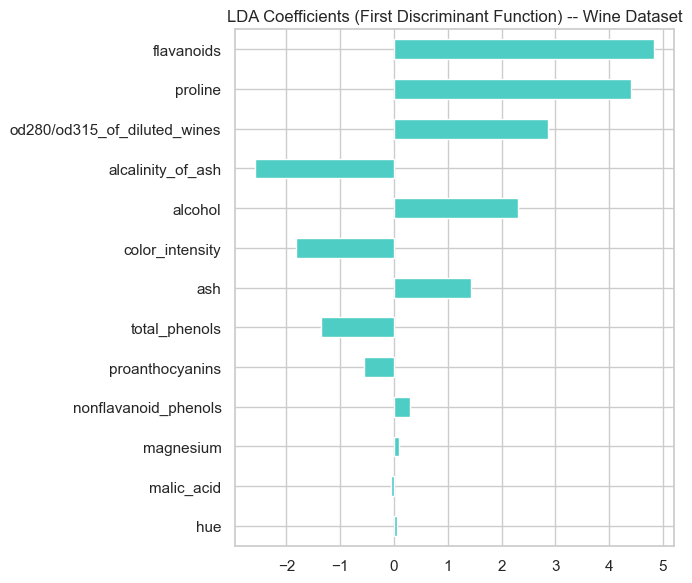

flavanoids                      4.833933
proline                         4.407904
od280/od315_of_diluted_wines    2.866183
alcalinity_of_ash              -2.588949
alcohol                         2.311586
dtype: float64


In [14]:
coef_series = pd.Series(lda_wine.coef_[0], index=wine.feature_names).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
coef_series.plot(kind="barh", ax=ax, color="#4ecdc4")
ax.set_title("LDA Coefficients (First Discriminant Function) -- Wine Dataset")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(coef_series.head(5))


## 15. Predicted Probabilities — LDA vs QDA Calibration

Both models expose `predict_proba()` (derived from Bayes' theorem, same as GaussianNB). Comparing confidence on a few test points shows how the extra flexibility QDA has can produce more (over)confident probability estimates on limited data.


In [15]:
sample_test = X_test[:5]
lda_probs = lda_model.predict_proba(sample_test)
qda_probs = qda_model.predict_proba(sample_test)

comparison = pd.DataFrame({
    "true_label": y_test.values[:5] if hasattr(y_test, "values") else y_test[:5],
    "LDA_max_prob": lda_probs.max(axis=1).round(3),
    "QDA_max_prob": qda_probs.max(axis=1).round(3),
})
comparison


,true_label,LDA_max_prob,QDA_max_prob
0,0,1.000,1.0
1,2,0.999,1.0
2,0,1.000,1.0
3,1,0.980,1.0
4,1,1.000,1.0


## ✅ Key Takeaways

- LDA and QDA are Gaussian generative classifiers, exactly like GaussianNB, but they model the **full covariance matrix** instead of assuming feature independence — closing the loop back to the Math Refresher's covariance/eigenvector math.
- **LDA assumes shared covariance across classes** → linear boundary, fewer parameters, more data-efficient. **QDA assumes per-class covariance** → quadratic boundary, more flexible, needs more data per class to estimate reliably.
- LDA has a second use beyond classification: **supervised dimensionality reduction**, finding axes that maximize class separation — a direct, labeled counterpart to PCA's unsupervised, variance-maximizing axes.
- Matching the model's covariance assumption to the data's real structure matters more than picking "the more flexible option by default" — QDA is not strictly better than LDA, section 5 shows it losing when its extra flexibility isn't actually needed.
- With small training sets, QDA's extra parameters become a liability (section 11) — LDA's simpler, shared-covariance assumption often wins purely on data efficiency, not correctness.

**Next up:** [08_Boosting_Classifiers](../08_Boosting_Classifiers/) — the last algorithm in this category, and the most powerful ensemble technique covered in this series.
